# <b> CRBL MF v25 REV 02</b>

<b> authors: Roberta Maria Lorenzi </b>

<b> version 1) - Integration of PLV weigths -  July, 2025</b>

contacts: robertamaria.lorenzi01@universitadipavia.it

## What is new?
Update version of Cerebellar mean-field (CRBL-MF v25) based on a mouse-awake configurations.
Pipeline for deriving mean-field parameters from SNN is authomatized:
- Synaptic convergence is weighted for PLV
- Quantal synaptic convergence and Synaptic time decay are cmputed as the average fo multiple synaptic conenction in SNN.



## Mean field model simulations

Testing

In [33]:
#import the libraries
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from plot_utils import *
import sys
sys.path.append('../')
import os

from load_config_TF import *
from master_equation_CRBL_MF import *
from theoretical_tools import *

In [34]:
root_path = os.getcwd()+'/' #folder where P coefficients were stored
NTWK = 'CRBL_CONFIG_AUTOMFM_AWAKE_FIT_5'
NTWK_hyp = 'CRBL_CONFIG_AUTOMFM_AWAKE_FIT_5_5_bis' #autism-like; Soda et al.,2019,J.ofNeurosci.
NTWK_red = 'CRBL_CONFIG_AUTOMFM_AWAKE_FIT_5_m6' #schizofrenia-like; Vergani et al.,2025,Poster

FILE_GrC = root_path  + '20250904_101211_GrC_CRBL_CONFIG_AUTOMFM_AWAKE_KmfgrcPLV_tsim5_alpha2.6_fit.npy'
FILE_GrC_hyp = root_path  + '20251009_214051_GrC_CRBL_CONFIG_AUTOMFM_AWAKE_FIT_5_5_bis_tsim5_alpha4.2_fit.npy'
FILE_GrC_red = root_path  + '20251103_194645_GrC_CRBL_CONFIG_AUTOMFM_AWAKE_FIT_5_m6_tsim5_alpha1.0_fit.npy'

FILE_GoC = root_path + '20250903_213910_GoC_CRBL_CONFIG_AUTOMFM_AWAKE_KgrcgocSUM_tsim5_alpha1.9_fit.npy'
FILE_MLI = root_path + '20250903_184431_MLI_CRBL_CONFIG_AUTOMFM_AWAKE_MLIMLIxPLV_tsim5_alpha1.8_fit.npy'
FILE_PC = root_path + '20250903_190157_PC_CRBL_CONFIG_AUTOMFM_AWAKE_Qmlipc1.22_KgrcpcSUM_tsim5_alpha1.8_fit.npy'

NRN1, NRN2, NRN3, NRN4 = 'GrC', 'GoC', 'MLI', 'PC'

aa = [3.00, 2.51, 4.31, 9.24] #thr=0.0015 & 0.0020
aa_hyp = 4.2
aa_red = 1.0

TFgrc = load_transfer_functions(NRN1, NTWK, FILE_GrC, alpha=aa[0])
TF_grc_hyp = load_transfer_functions(NRN1, NTWK_hyp, FILE_GrC_hyp, alpha=aa_hyp)
TF_grc_red = load_transfer_functions(NRN1, NTWK_red, FILE_GrC_red, alpha=aa_red)

TFgoc = load_transfer_functions_goc(NRN2, NTWK, FILE_GoC, alpha=aa[1])
TFmli = load_transfer_functions(NRN3, NTWK, FILE_MLI, alpha=aa[2])
TFpc = load_transfer_functions(NRN4, NTWK, FILE_PC, alpha=aa[3])




************* STANDARD TF CONFIGURATION ************
************* STANDARD TF CONFIGURATION ************
************* STANDARD TF CONFIGURATION ************
************* STANDARD TF CONFIGURATION ************


In [35]:
## Standard parameters
Ngrc = 29916
Ngoc = 71
Nmossy = 2340
Nmli = 302+150
Npc = 69

dt = 1e-4
sim_len = 0.5
t = np.arange(0, sim_len, dt)

T = 3.5e-3
w = 0. #adaptation not included at the moment

In [171]:
def get_three_ticks(data, variance):
        y_min = np.min(data - np.sqrt(abs(variance)))
        y_max = np.max(data + np.sqrt(abs(variance)))
        y_mid = (y_min + y_max) / 2

        if y_min < 0: y_min=0
        return [round(y_min), round(y_mid), round(y_max)]

def plot_MF_activity_withSD_m(t, X, finput, mytitle, col_vec, alpha, X_ticks, font_size=22, linew=1.5, lines = '-', mark = '-', axes=None):
    """
    Se axes è None, crea una nuova figura con 5 subplot.
    Se axes è passato, disegna sugli assi esistenti.
    """
    if axes is None:
        fig, axes = plt.subplots(5, 1, figsize=(2.4, 4.1))
        fig.suptitle(mytitle, fontsize=font_size + 2)
    else:
        fig = axes[0].figure  # recupera la figura dagli assi

    ax1, ax2, ax3, ax4, ax5 = axes

    # PC
    ax1.plot(t, X[:, 10], col_vec[0], linewidth=linew, alpha=alpha, linestyle = lines, marker = mark)
    ax1.fill_between(t, X[:, 10] - np.sqrt(abs(X[:, 15])), X[:, 10] + np.sqrt(abs(X[:, 15])),
                     color=col_vec[0], alpha=0.15)
    ax1.set_yticks(X_ticks[0])
    #ax1.set_xticks([])
    ax1.set_xticks(np.round(np.linspace(0, 0.5, 3, endpoint=True),2))

    # MLI
    ax2.plot(t, X[:, 9], col_vec[1], linewidth=linew, alpha=alpha, linestyle = lines, marker = mark)
    ax2.fill_between(t, X[:, 9] - np.sqrt(abs(X[:, 11])), X[:, 9] + np.sqrt(abs(X[:, 11])),
                     color=col_vec[1], alpha=0.15)
    ax2.set_yticks(X_ticks[1])
    ax2.set_xticks(np.round(np.linspace(0, 0.5, 3, endpoint=True),2))

    # GoC
    ax3.plot(t, X[:, 1], col_vec[2], linewidth=linew, alpha=alpha, linestyle = lines, marker = mark)
    ax3.fill_between(t, X[:, 1] - np.sqrt(abs(X[:, 6])), X[:, 1] + np.sqrt(abs(X[:, 6])),
                     color=col_vec[2], alpha=0.15)
    ax3.set_ylabel(r'$\nu$ [Hz]', fontsize=font_size, ha='center', va='center', labelpad=20)
    ax3.set_yticks(X_ticks[2])
    ax3.set_xticks(np.round(np.linspace(0, 0.5, 3, endpoint=True),2))

    # GrC
    ax4.plot(t, X[:, 0], col_vec[3], linewidth=linew, alpha=alpha, linestyle = lines, marker = mark)
    ax4.fill_between(t, X[:, 0] - np.sqrt(abs(X[:, 2])), X[:, 0] + np.sqrt(abs(X[:, 2])),
                     color=col_vec[3], alpha=0.15)
    ax4.set_yticks(X_ticks[3])
    ax4.set_xticks(np.round(np.linspace(0, 0.5, 3, endpoint=True),2))

    # Input (solo una volta, ma se vuoi puoi plottarlo più volte)
    ax5.plot(t, finput, 'black', linewidth=linew*0.5, alpha = alpha)
    ax5.set_yticks(X_ticks[4])
    ax5.set_xticks(np.round(np.linspace(0, 0.5, 3, endpoint=True),2))
    ax5.set_xlabel('t [s]', fontsize=font_size, ha='center', va='center', labelpad=20)

    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.subplots_adjust(hspace=0.5, top=0.92, bottom=0.1)

    return fig, axes

### Background noise

#### checking model response at baseline

In [38]:
f_backnoise = np.random.rand(len(t))*4 #background noise set around 4 Hz

In [39]:
CI_vec = [0.5, 5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, f_backnoise[0], 15, 38, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]

X_back = find_fixed_point_mossy(TFgrc, TFgoc, TFmli, TFpc, CI_vec, t, w, f_backnoise,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)

X_back_hyp = find_fixed_point_mossy(TF_grc_hyp, TFgoc, TFmli, TFpc, CI_vec, t, w, f_backnoise,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)

X_back_red = find_fixed_point_mossy(TF_grc_red, TFgoc, TFmli, TFpc, CI_vec, t, w, f_backnoise,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)

### Gaussian input

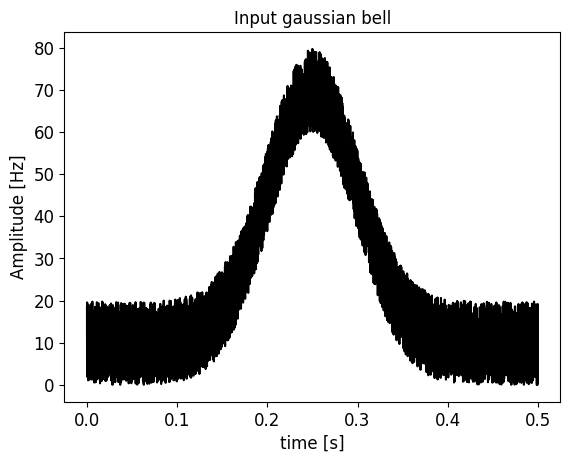

In [41]:
mu = t[len(t)//2]       # center
sigma = 0.05            # width (standard deviation)
amp = 60.0              # amplitude

# gauss function
gauss = amp * np.exp(-0.5 * ((t - mu) / sigma)**2)
f_gauss_back = gauss + np.random.rand(len(t))*0.33*amp

## check the input
plt.plot(t, f_gauss_back, color = 'black')
plt.title("Input gaussian bell", fontsize=12)
plt.xlabel("time [s]", fontsize=12)
plt.ylabel("Amplitude [Hz]", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [42]:
CI_vec = [0.5, 5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, f_backnoise[0], 15, 38, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]

X_gauss = find_fixed_point_mossy(TFgrc, TFgoc, TFmli, TFpc, CI_vec, t, w, f_gauss_back,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)
X_gauss_hyp = find_fixed_point_mossy(TF_grc_hyp, TFgoc, TFmli, TFpc, CI_vec, t, w, f_gauss_back,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)
X_gauss_red = find_fixed_point_mossy(TF_grc_red, TFgoc, TFmli, TFpc, CI_vec, t, w, f_gauss_back,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)

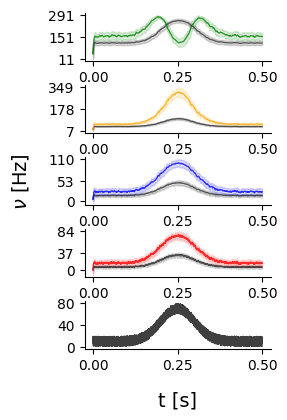

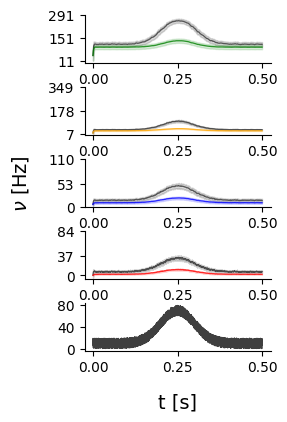

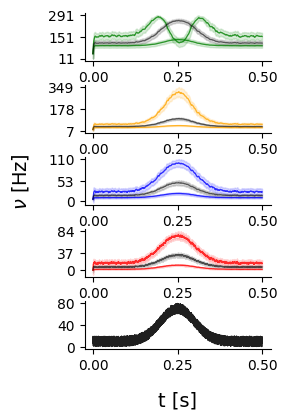

In [129]:
X_ticks_PC=get_three_ticks(X_gauss_hyp[:, 10], X_gauss_hyp[:, 15])
X_ticks_MLI = get_three_ticks(X_gauss_hyp[:, 9], X_gauss_hyp[:, 11])
X_ticks_GoC = get_three_ticks(X_gauss_hyp[:, 1], X_gauss_hyp[:, 6])
X_ticks_GrC = get_three_ticks(X_gauss_hyp[:, 0], X_gauss_hyp[:, 2])
X_ticks_input = get_three_ticks(f_gauss_back, np.zeros_like(f_gauss_back))

X_ticks = [X_ticks_PC, X_ticks_MLI, X_ticks_GoC, X_ticks_GrC, X_ticks_input]

fig, axes = plot_MF_activity_withSD_m(t, X_gauss, f_gauss_back, "", 
                                      col_vec = ['black','black','black','black'], 
                                      alpha = 0.6, X_ticks = X_ticks, font_size=14, linew=0.95)

plot_MF_activity_withSD_m(t, X_gauss_hyp, f_gauss_back, "", 
                          col_vec = ['green','orange','blue','red'], 
                          alpha = 0.8, X_ticks = X_ticks, font_size=14, linew=0.95, axes=axes)
plt.show()
fig.savefig("grc_exp_pred_gauss_pulse.png", dpi=300, bbox_inches="tight")


fig_r, axes_r = plot_MF_activity_withSD_m(t, X_gauss, f_gauss_back, "", 
                                      col_vec = ['black','black','black','black'], 
                                      alpha = 0.6, X_ticks = X_ticks, font_size=14, linew=0.95)

plot_MF_activity_withSD_m(t, X_gauss_red, f_gauss_back, "", 
                          col_vec = ['green','orange','blue','red'], 
                          alpha = 0.8, X_ticks = X_ticks, font_size=14, linew=0.95, axes=axes_r)
plt.show()
fig_r.savefig("grc_exp_pred_gauss_pulse_red.png", dpi=300, bbox_inches="tight")


# # All in one plot
fig_all, axes_all =  plot_MF_activity_withSD_m(t, X_gauss_hyp, f_gauss_back, "", 
                          col_vec = ['green','orange','blue','red'], 
                          alpha = 0.8, X_ticks = X_ticks, font_size=14, linew=0.95)

plot_MF_activity_withSD_m(t, X_gauss_red, f_gauss_back, "", 
                          col_vec = ['green','orange','blue','red'], 
                          alpha = 0.8, X_ticks = X_ticks, font_size=14, linew=0.95, axes=axes_all)

plot_MF_activity_withSD_m(t, X_gauss, f_gauss_back, "", 
                                      col_vec = ['black','black','black','black'], 
                                      alpha = 0.6, X_ticks = X_ticks, font_size=14, linew=0.95, axes=axes_all)


plt.show()
fig_all.savefig("grc_exp_pred_gauss_pulse_all.png", dpi=300, bbox_inches="tight")



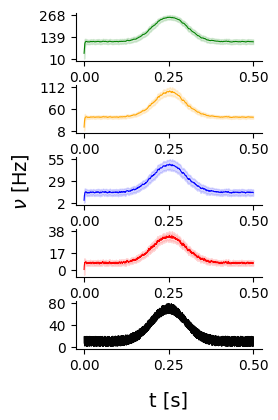

In [184]:
X_ticks_PC=get_three_ticks(X_gauss[:, 10], X_gauss[:, 15])
X_ticks_MLI = get_three_ticks(X_gauss[:, 9], X_gauss[:, 11])
X_ticks_GoC = get_three_ticks(X_gauss[:, 1], X_gauss[:, 6])
X_ticks_GrC = get_three_ticks(X_gauss[:, 0], X_gauss[:, 2])
X_ticks_input = get_three_ticks(f_gauss_back, np.zeros_like(f_gauss_back))
X_ticks = [X_ticks_PC, X_ticks_MLI, X_ticks_GoC, X_ticks_GrC, X_ticks_input]



fig_stim, axes_stim = plot_MF_activity_withSD_m(t, X_gauss, f_gauss_back, "", 
                                        col_vec = ['green','orange','blue','red'], 
                                        alpha = 0.99, X_ticks=X_ticks, font_size=14, linew=0.8)

fig_stim.savefig("grc_exp_pred_gauss_gauss_stim.png", dpi=300, bbox_inches="tight")

Centri gaussiane: [0.1  0.25 0.4 ]


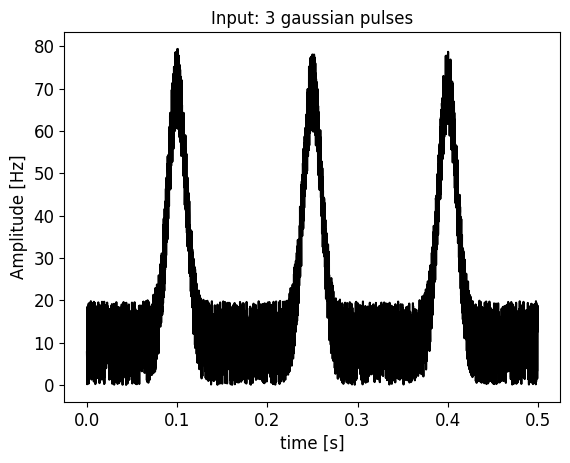

In [130]:
# Parametri
sigma = 0.01   # larghezza (non la tocchiamo)
amp = 60.0     # ampiezza
n_pulses = 3   # numero di impulsi
start = 0.1   # centro del primo impulso
end = 0.40     # centro dell'ultimo impulso

# Calcolo dei centri equispaziati
mu_values = np.linspace(start, end, n_pulses)
print("Centri gaussiane:", mu_values)

# Costruzione del segnale con 3 gaussiane
f_gauss_back_3 = np.zeros_like(t)
for mu in mu_values:
    gauss = amp * np.exp(-0.5 * ((t - mu) / sigma)**2)
    f_gauss_back_3 += gauss

# Aggiunta di rumore
f_gauss_back_3 += np.random.rand(len(t)) * 0.33 * amp

# Plot
plt.plot(t, f_gauss_back_3, color='black')
plt.title("Input: 3 gaussian pulses", fontsize=12)
plt.xlabel("time [s]", fontsize=12)
plt.ylabel("Amplitude [Hz]", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [46]:
CI_vec = [0.5, 5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, f_backnoise[0], 15, 38, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]

X_gauss_3 = find_fixed_point_mossy(TFgrc, TFgoc, TFmli, TFpc, CI_vec, t, w, f_gauss_back_3,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)
X_gauss_hyp_3 = find_fixed_point_mossy(TF_grc_hyp, TFgoc, TFmli, TFpc, CI_vec, t, w, f_gauss_back_3,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)
X_gauss_red_3 = find_fixed_point_mossy(TF_grc_red, TFgoc, TFmli, TFpc, CI_vec, t, w, f_gauss_back_3,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)

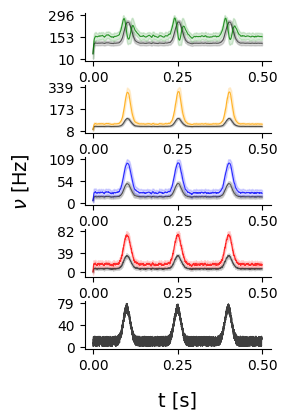

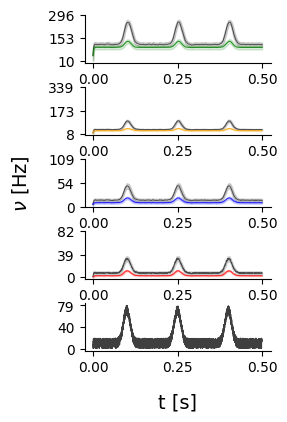

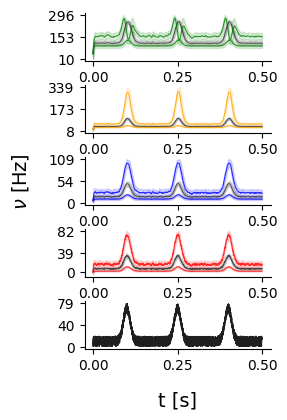

In [131]:
X_ticks_PC=get_three_ticks(X_gauss_hyp_3[:, 10], X_gauss_hyp_3[:, 15])
X_ticks_MLI = get_three_ticks(X_gauss_hyp_3[:, 9], X_gauss_hyp_3[:, 11])
X_ticks_GoC = get_three_ticks(X_gauss_hyp_3[:, 1], X_gauss_hyp_3[:, 6])
X_ticks_GrC = get_three_ticks(X_gauss_hyp_3[:, 0], X_gauss_hyp_3[:, 2])
X_ticks_input = get_three_ticks(f_gauss_back_3, np.zeros_like(f_gauss_back_3))
X_ticks = [X_ticks_PC, X_ticks_MLI, X_ticks_GoC, X_ticks_GrC, X_ticks_input]



fig3, axes3 = plot_MF_activity_withSD_m(t, X_gauss_3, f_gauss_back_3, "", 
                                        col_vec = ['black','black','black','black'], 
                                        alpha = 0.6, X_ticks = X_ticks, font_size=14, linew=0.8)

plot_MF_activity_withSD_m(t, X_gauss_hyp_3, f_gauss_back_3, "", 
                          col_vec = ['green','orange','blue','red'], 
                          alpha = 0.8, X_ticks = X_ticks, font_size=14, linew=0.8, axes=axes3)
plt.show()
fig3.savefig("grc_exp_pred_gauss_3_pulse.png", dpi=300, bbox_inches="tight")



fig3_r, axes3_r = plot_MF_activity_withSD_m(t, X_gauss_3, f_gauss_back_3, "", 
                                        col_vec = ['black','black','black','black'], 
                                        alpha = 0.6, X_ticks = X_ticks, font_size=14, linew=0.8)

plot_MF_activity_withSD_m(t, X_gauss_red_3, f_gauss_back_3, "", 
                          col_vec = ['green','orange','blue','red'], 
                          alpha = 0.8, X_ticks = X_ticks, font_size=14, linew=0.8, axes=axes3_r)
plt.show()
fig3_r.savefig("grc_exp_pred_gauss_3_pulse_r.png", dpi=300, bbox_inches="tight")



fig3_all, axes3_all = plot_MF_activity_withSD_m(t, X_gauss_3, f_gauss_back_3, "", 
                                        col_vec = ['black','black','black','black'], 
                                        alpha = 0.6, X_ticks = X_ticks, font_size=14, linew=0.8)

plot_MF_activity_withSD_m(t, X_gauss_hyp_3, f_gauss_back_3, "", 
                          col_vec = ['green','orange','blue','red'], 
                          alpha = 0.8, X_ticks = X_ticks, font_size=14, linew=0.8, axes=axes3_all)

plot_MF_activity_withSD_m(t, X_gauss_red_3, f_gauss_back_3, "", 
                          col_vec = ['green','orange','blue','red'], 
                          alpha = 0.8, X_ticks = X_ticks, font_size=14, linew=0.8, axes=axes3_all)
plt.show()
fig3_all.savefig("grc_exp_pred_gauss_3_pulse_all.png", dpi=300, bbox_inches="tight")

### Cortical like input

In [203]:
f_backnoise = np.ones_like(t)*4
amplitude = 7.5
freq1 = 15
freq2 = 30
freq3 = 1
f_sin1 = amplitude * np.sin(2 * np.pi * freq1 * t) + amplitude
f_sin2 = amplitude * np.sin(2*np.pi*freq2*t)+ amplitude
f_sin3 = amplitude * np.sin(2 * np.pi * freq3 * t) + amplitude

fmulti_sin = f_sin1 + f_sin2 + f_sin3
fmossy_cort = fmulti_sin + f_backnoise

In [204]:
# X = vector of activity with Vp = population p mean activity, Csp = covariance between population s and p

# X = [Vgrc, Vgoc, Cgrcgrc, Cgrcgoc, Cgrcm, Cmgoc, Cgocgoc, Cmm, Vm, Vmli, Vpc, Cmlimli, Cmlipc, Cgrcpc, Cgrcmli,
#     Cpcpc, Cmligoc, Cmlimossy, Cpcgoc, Cpcmossy]


CI_vec = [0.5, 5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, fmossy_cort[0], 15, 38, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]

X_cort = find_fixed_point_mossy(TFgrc, TFgoc, TFmli, TFpc, CI_vec, t, w, fmossy_cort,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)
X_cort_hyp = find_fixed_point_mossy(TF_grc_hyp, TFgoc, TFmli, TFpc, CI_vec, t, w, fmossy_cort,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)
X_cort_red = find_fixed_point_mossy(TF_grc_red, TFgoc, TFmli, TFpc, CI_vec, t, w, fmossy_cort,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)

/home/bcc/projects/BSB4_demo/cerebellum_zmin_plv_Ie780_debug_corrected_GrCexploration/theoretical_tools.py:102: RuntimeWarning:

invalid value encountered in sqrt



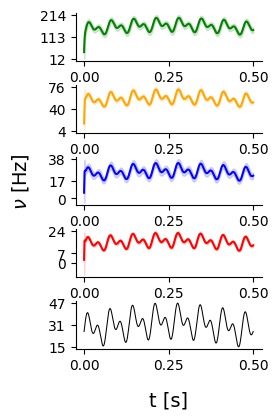

In [205]:
X_ticks_PC=get_three_ticks(X_cort[:, 10], X_cort[:, 15])
X_ticks_MLI = get_three_ticks(X_cort[:, 9], X_cort[:, 11])
X_ticks_GoC = get_three_ticks(X_cort[:, 1], X_cort[:, 6])
X_ticks_GrC = get_three_ticks(X_cort[:, 0], X_cort[:, 2])
X_ticks_input = get_three_ticks(fmossy_cort, np.zeros_like(fmossy_cort))
X_ticks = [X_ticks_PC, X_ticks_MLI, X_ticks_GoC, X_ticks_GrC, X_ticks_input]



fig_cort, axes_cort = plot_MF_activity_withSD_m(t, X_cort, fmossy_cort, "", 
                                        col_vec = ['green','orange','blue','red'], 
                                        alpha = 0.99, X_ticks = X_ticks, font_size=14, linew=1.5)

plt.show()
fig_cort.savefig("grc_exp_pred_cort.png", dpi=300, bbox_inches="tight")

### Sensory like input

In [58]:
def rect_input(time, t_start, t_end, minval, freq, noise_freq):

    """
    time = time vector of simulation
    t_start = start of the step INDEX
    t_end = end of the step INDEX
    minval = baseline value (deviation from 0)
    freq = peak value
    noise_freq = random noise frequencies
    """

    y = np.ones(len(time)) * freq + np.random.rand(len(time)) * noise_freq
    y[:t_start] = y[:t_start]*0+np.random.rand(t_start)*noise_freq
    y[t_end:] = y[t_end:]*0+np.random.rand(len(time) - t_end)*noise_freq
    y = y + minval

    return y

In [59]:
f_tone = rect_input(time=t, t_start=100, t_end=4500, minval=0, freq=40, noise_freq=0)
#f_tone1 = rect_input(time=t, t_start=700, t_end=1200, minval=0, freq=40, noise_freq=0)
#f_tone2 = rect_input(time=t, t_start=1300, t_end=1800, minval=0, freq=40, noise_freq=0)
#f_tone3 = rect_input(time=t, t_start=1900, t_end=1400, minval=0, freq=40, noise_freq=0)
#fmossy_sens = fmossy_cort + f_tone
fmossy_sens =f_backnoise+f_tone #f_tone1 + f_tone2 + f_tone3
print(np.max(fmossy_sens))

43.99986752794788


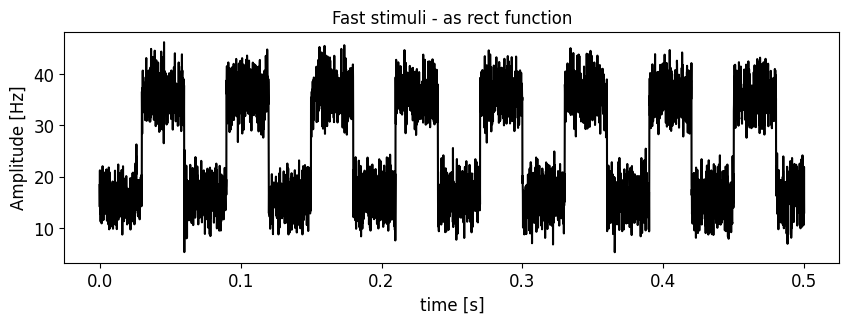

In [178]:
rect_duration = 300  #300*0.1ms = 30ms
rect_interval = 600  # distance of one stim to another: 600*0.1 = 60ms
start_idx = int(0.03 / dt)  # 200 ms dall'inizio
freq = 20
minval = 0
noise_freq = 4

signal = np.ones(len(t)) * minval
for i in range(8):
    s = start_idx + i * rect_interval
    e = s + rect_duration
    if e > len(t):
        e = len(t)
    signal = signal + rect_input(t, s, e, minval, freq, noise_freq)

f_sens_fast = signal + f_backnoise
plt.figure(figsize=(10,3))
plt.plot(t, f_sens_fast, color = 'black')
plt.xlabel('time [s]', fontsize=12)
plt.ylabel('Amplitude [Hz]', fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.title('Fast stimuli - as rect function')
plt.show()

In [179]:
# X = vector of activity with Vp = population p mean activity, Csp = covariance between population s and p

# X = [Vgrc, Vgoc, Cgrcgrc, Cgrcgoc, Cgrcm, Cmgoc, Cgocgoc, Cmm, Vm, Vmli, Vpc, Cmlimli, Cmlipc, Cgrcpc, Cgrcmli,
#     Cpcpc, Cmligoc, Cmlimossy, Cpcgoc, Cpcmossy]


CI_vec_sens = [0.5, 5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, fmossy_sens[0], 15, 38, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]

X_sens_fast = find_fixed_point_mossy(TFgrc, TFgoc, TFmli, TFpc, CI_vec_sens, t, w, f_sens_fast,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)

X_sens_fast_hyp = find_fixed_point_mossy(TF_grc_hyp, TFgoc, TFmli, TFpc, CI_vec_sens, t, w, f_sens_fast,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)

X_sens_fast_red = find_fixed_point_mossy(TF_grc_red, TFgoc, TFmli, TFpc, CI_vec_sens, t, w, f_sens_fast,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)


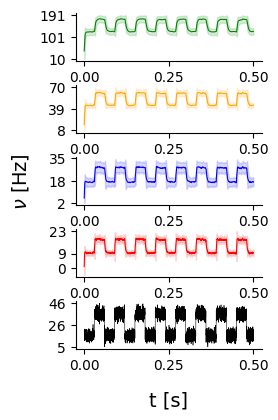

In [180]:
X_ticks_PC=get_three_ticks(X_sens_fast[:, 10], X_sens_fast[:, 15])
X_ticks_MLI = get_three_ticks(X_sens_fast[:, 9], X_sens_fast[:, 11])
X_ticks_GoC = get_three_ticks(X_sens_fast[:, 1], X_sens_fast[:, 6])
X_ticks_GrC = get_three_ticks(X_sens_fast[:, 0], X_sens_fast[:, 2])
X_ticks_input = get_three_ticks(f_sens_fast, np.zeros_like(f_sens_fast))
X_ticks = [X_ticks_PC, X_ticks_MLI, X_ticks_GoC, X_ticks_GrC, X_ticks_input]



fig_stim, axes_stim = plot_MF_activity_withSD_m(t, X_sens_fast, f_sens_fast, "", 
                                        col_vec = ['green','orange','blue','red'], 
                                        alpha = 0.99, X_ticks=X_ticks, font_size=14, linew=0.8)

fig_stim.savefig("grc_exp_pred_gauss_stim.png", dpi=300, bbox_inches="tight")

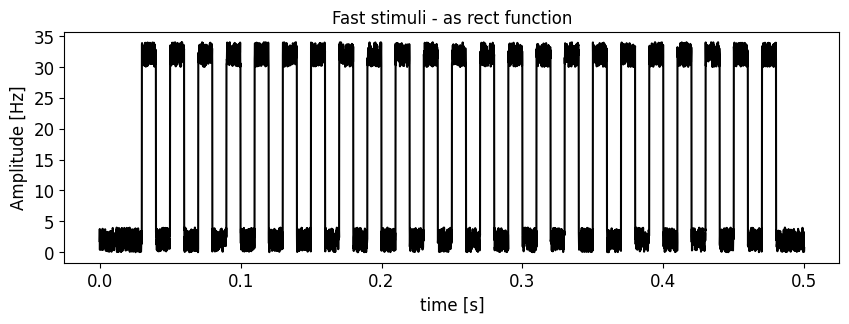

In [65]:
rect_duration = 100  #300*0.1ms = 30ms
rect_interval = 200  # distance of one stim to another: 600*0.1 = 60ms
start_idx = int(0.03 / dt)  # 200 ms dall'inizio
freq = 30
minval = 0
noise_freq = 0

signal = np.ones(len(t)) * minval
for i in range(23):
    s = start_idx + i * rect_interval
    e = s + rect_duration
    if e > len(t):
        e = len(t)
    signal = signal + rect_input(t, s, e, minval, freq, noise_freq)

f_sens_fast_fast = signal + f_backnoise
plt.figure(figsize=(10,3))
plt.plot(t, f_sens_fast_fast, color = 'black')
plt.xlabel('time [s]', fontsize=12)
plt.ylabel('Amplitude [Hz]', fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.title('Fast stimuli - as rect function')
plt.show()

In [66]:
# X = vector of activity with Vp = population p mean activity, Csp = covariance between population s and p

# X = [Vgrc, Vgoc, Cgrcgrc, Cgrcgoc, Cgrcm, Cmgoc, Cgocgoc, Cmm, Vm, Vmli, Vpc, Cmlimli, Cmlipc, Cgrcpc, Cgrcmli,
#     Cpcpc, Cmligoc, Cmlimossy, Cpcgoc, Cpcmossy]

"""
CI_vec_sens = [0.5, 5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, f_backnoise[0], 15, 38, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]

X_sens_fast_fast = find_fixed_point_mossy(TFgrc, TFgoc, TFmli, TFpc, CI_vec_sens, t, w, f_sens_fast_fast,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)

X_sens_fast_fast_hyp = find_fixed_point_mossy(TF_grc_hyp, TFgoc, TFmli, TFpc, CI_vec_sens, t, w, f_sens_fast_fast,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)

X_sens_fast_fast_red = find_fixed_point_mossy(TF_grc_red, TFgoc, TFmli, TFpc, CI_vec_sens, t, w, f_sens_fast_fast,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)
"""

'\nCI_vec_sens = [0.5, 5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, f_backnoise[0], 15, 38, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]\n\nX_sens_fast_fast = find_fixed_point_mossy(TFgrc, TFgoc, TFmli, TFpc, CI_vec_sens, t, w, f_sens_fast_fast,\n                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)\n\nX_sens_fast_fast_hyp = find_fixed_point_mossy(TF_grc_hyp, TFgoc, TFmli, TFpc, CI_vec_sens, t, w, f_sens_fast_fast,\n                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)\n\nX_sens_fast_fast_red = find_fixed_point_mossy(TF_grc_red, TFgoc, TFmli, TFpc, CI_vec_sens, t, w, f_sens_fast_fast,\n                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)\n'

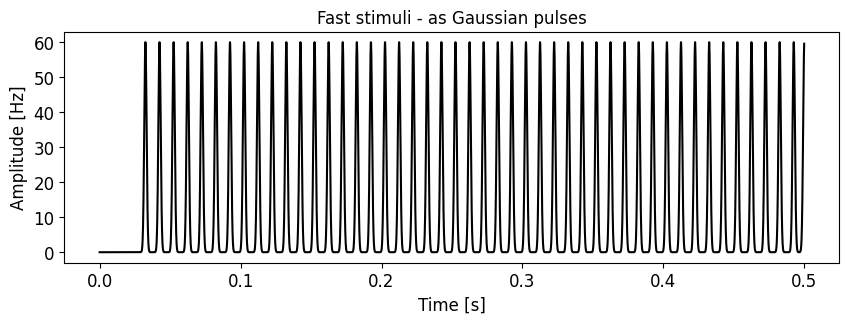

In [68]:
# Parameters stimolus
rect_duration = 50 #100        # duration (pti)
rect_interval = 100 #200        # interval (pti)
start_idx = int(0.03 / dt) # 30 ms
freq = 60
minval = 0
noise_freq = 0

f_backnoise = np.random.rand(len(t)) * 0
signal = np.ones(len(t)) * minval

# Bells
for i in range(50): #25
    s = start_idx + i * rect_interval
    e = s + rect_duration
    if e > len(t):
        e = len(t)
    center = (s + e) / 2
    sigma = rect_duration / 6  #bell width (≈99% within stdev)
    signal += freq * np.exp(-0.5 * ((np.arange(len(t)) - center) / sigma)**2)

f_sens_fast_fast_bell = signal + f_backnoise


plt.figure(figsize=(10,3))
plt.plot(t, f_sens_fast_fast_bell, color='black')
plt.xlabel('Time [s]', fontsize=12)
plt.ylabel('Amplitude [Hz]', fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.title('Fast stimuli - as Gaussian pulses')
plt.show()


In [69]:
CI_vec_sens = [0.5, 5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, f_backnoise[0], 15, 38, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]

X_sens_fast_fast_bell = find_fixed_point_mossy(TFgrc, TFgoc, TFmli, TFpc, CI_vec_sens, t, w, f_sens_fast_fast_bell,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)

X_sens_fast_fast_bell_hyp = find_fixed_point_mossy(TF_grc_hyp, TFgoc, TFmli, TFpc, CI_vec_sens, t, w, f_sens_fast_fast_bell,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)

X_sens_fast_fast_bell_red = find_fixed_point_mossy(TF_grc_red, TFgoc, TFmli, TFpc, CI_vec_sens, t, w, f_sens_fast_fast_bell,
                           Ngrc, Ngoc, Nmossy, Nmli, Npc, T, verbose=False)

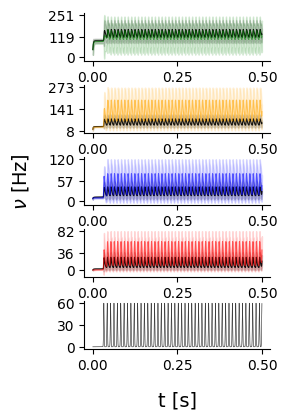

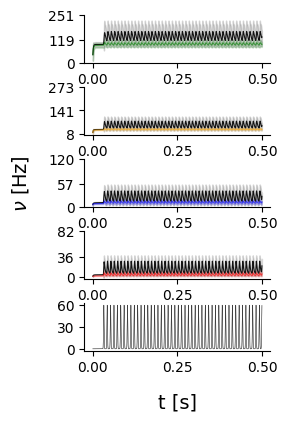

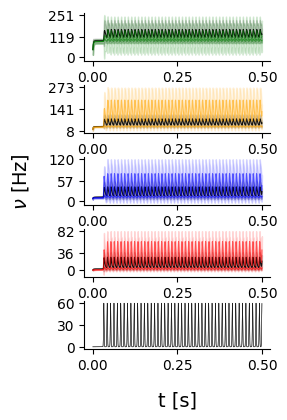

In [132]:
X_ticks_PC=get_three_ticks(X_sens_fast_fast_bell_hyp[:, 10], X_sens_fast_fast_bell_hyp[:, 15])
X_ticks_MLI = get_three_ticks(X_sens_fast_fast_bell_hyp[:, 9], X_sens_fast_fast_bell_hyp[:, 11])
X_ticks_GoC = get_three_ticks(X_sens_fast_fast_bell_hyp[:, 1], X_sens_fast_fast_bell_hyp[:, 6])
X_ticks_GrC = get_three_ticks(X_sens_fast_fast_bell_hyp[:, 0], X_sens_fast_fast_bell_hyp[:, 2])
X_ticks_input = get_three_ticks(f_sens_fast_fast_bell, np.zeros_like(f_sens_fast_fast_bell))
X_ticks = [X_ticks_PC, X_ticks_MLI, X_ticks_GoC, X_ticks_GrC, X_ticks_input]



fig2, axes2 = plot_MF_activity_withSD_m(t, X_sens_fast_fast_bell, f_sens_fast_fast_bell, "", 
                                        col_vec = ['black','black','black','black'], 
                                        alpha = 0.9, X_ticks=X_ticks, font_size=14, linew=0.8)

plot_MF_activity_withSD_m(t, X_sens_fast_fast_bell_hyp, f_sens_fast_fast_bell, "", 
                          col_vec = ['green','orange','blue','red'], 
                          alpha = 0.6, X_ticks=X_ticks, font_size=14, linew=0.8, axes=axes2)

plt.show()
fig2.savefig("grc_exp_pred_gauss_fast_fast.png", dpi=300, bbox_inches="tight")


fig2_r, axes2_re = plot_MF_activity_withSD_m(t, X_sens_fast_fast_bell, f_sens_fast_fast_bell, "", 
                                        col_vec = ['black','black','black','black'], 
                                        alpha = 0.9, X_ticks=X_ticks, font_size=14, linew=0.8)

plot_MF_activity_withSD_m(t, X_sens_fast_fast_bell_red, f_sens_fast_fast_bell, "", 
                          col_vec = ['green','orange','blue','red'], 
                          alpha = 0.6, X_ticks=X_ticks, font_size=14, linew=0.8, axes=axes2_re)

plt.show()
fig2_r.savefig("grc_exp_pred_gauss_fast_fast_red.png", dpi=300, bbox_inches="tight")



fig2_all, axes2_all = plot_MF_activity_withSD_m(t, X_sens_fast_fast_bell, f_sens_fast_fast_bell, "", 
                                        col_vec = ['black','black','black','black'], 
                                        alpha = 0.9, X_ticks=X_ticks, font_size=14, linew=0.8)

plot_MF_activity_withSD_m(t, X_sens_fast_fast_bell_hyp, f_sens_fast_fast_bell, "", 
                          col_vec = ['green','orange','blue','red'], 
                          alpha = 0.6, X_ticks=X_ticks, font_size=14, linew=0.8, axes=axes2_all)

plot_MF_activity_withSD_m(t, X_sens_fast_fast_bell_red, f_sens_fast_fast_bell, "", 
                          col_vec = ['green','orange','blue','red'], 
                          alpha = 0.6, X_ticks=X_ticks, font_size=14, linew=0.8, axes=axes2_all)

plt.show()
fig2_all.savefig("grc_exp_pred_gauss_fast_fast.png", dpi=300, bbox_inches="tight")

## References:

- Cerebellar MF model: Lorenzi et al. 2023 (https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1011434)
- E-GLIF: Geminiani et al. 2018, 2019 (https://doi.org/10.3389/fninf.2018.00088 and https://doi.org/10.3389/fncom.2019.00035)
- BSB: De Schepper et al. 2022 (https://doi.org/10.1038/s42003-022-04213-y)
- Mathematics: Boustani and Destexhe 2009 (https://doi.org/10.1162/neco.2009.02-08-710)
- TF formalism: Zerlaut et al. 2018 (https://doi.org/10.1007/s10827-017-0668-2)
- TF Fitting procedure: Zerlaut et al. 2016  (https://doi.org/10.1113/JP272317)
- MF with adaptation: Di Volo et al. 2019 (https://doi.org/10.1162/neco_a_01173)
- MF review for different neuron model: Carlu et al. 2020 (https://doi.org/10.1152/jn.00399.2019)